In [1]:
import pandas as pd
import numpy as np
from math import sin, cos, atan2, sqrt, radians
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv(
    'data/Bezoeken per voertuig 01-01-2025 - 31-12-2025.Csv',
    sep=';',
    encoding='utf-16',
    skiprows=1
)

C:\Users\aniek.kasius\AppData\Local\Temp\ipykernel_20568\1523193955.py:1: DtypeWarning: Columns (0: Contact) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [4]:
# Datum en tijd goed zetten
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Sorteren op echte ritvolgorde
df = df.sort_values(["Date", "SerialNumber", "StartRide"]).copy()

In [5]:
df

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long
4156,1040 (VFT-36-H),2025-01-01,13:57,13:57,13:59,"0,00",00:00,0:01,"Dokter Rietveldplein 22, Papendrecht",NaN,NaN,BBT Dordrecht/MHG,NaN,NaN,Dokter Rietveldplein 22,3353SJ,Papendrecht,NaN,0:00,0:02,0:00,0:01,0:00,"0,00",51.823878,4.689373
4157,1040 (VFT-36-H),2025-01-01,13:59,14:00,07:04,"0,17",00:00,17:04,"Dokter Rietveldplein 22, Papendrecht",NaN,NaN,BBT Dordrecht/MHG,NaN,NaN,Dokter Rietveldplein 22,3353SJ,Papendrecht,NaN,0:00,0:03,0:01,0:01,0:03,"0,17",51.823918,4.689510
23890,1326 (VNT-05-X),2025-01-01,10:52,10:54,06:48,"0,56",00:01,19:54,"Slobbengorsweg 100, Papendrecht",NaN,NaN,BBT Dordrecht/MHG,NaN,NaN,Slobbengorsweg 100,3351LH,Papendrecht,NaN,0:00,0:01,0:01,0:00,0:01,"0,56",51.823409,4.677820
34792,1515 (VVF-65-D),2025-01-01,10:28,11:12,11:28,"55,60",00:43,0:15,"Onyxdijk 167, Roosendaal",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Onyxdijk 167,4706LL,Roosendaal,NaN,0:00,0:59,0:43,0:15,0:00,"55,60",51.518796,4.492111
34793,1515 (VVF-65-D),2025-01-01,11:28,12:08,12:14,"52,00",00:39,0:05,"Prickwaert 66, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Prickwaert 66,3363BD,Sliedrecht,NaN,0:00,1:45,1:23,0:21,0:00,"107,60",51.827532,4.758798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59128,1775 (V-11-GGL),2025-12-31,09:17,09:28,10:18,"5,81",00:10,0:50,"Van Beethovenlaan 56, Rotterdam",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Van Beethovenlaan 56,3055JD,Rotterdam,NaN,0:00,3:50,1:27,2:22,0:00,"68,85",51.956123,4.512793
59129,1775 (V-11-GGL),2025-12-31,10:18,10:38,10:57,"6,61",00:19,0:19,"Dotterlei 143, Capelle Aan Den Ijssel",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Dotterlei 143,2906BC,Capelle Aan Den Ijssel,NaN,0:00,4:29,1:47,2:42,0:00,"75,46",51.932790,4.563842
59130,1775 (V-11-GGL),2025-12-31,10:57,11:28,11:46,"22,78",00:30,0:17,"Groen Van Prinstererweg 38, Dordrecht",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Groen Van Prinstererweg 38,3317SP,Dordrecht,NaN,0:00,5:18,2:18,3:00,0:00,"98,24",51.790982,4.665400
59131,1775 (V-11-GGL),2025-12-31,11:46,11:54,12:02,"1,99",00:08,0:07,"Minnaertweg 4, Dordrecht",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Minnaertweg 4,3328HN,Dordrecht,NaN,0:00,5:34,2:26,3:07,0:00,"100,23",51.783413,4.686293


In [6]:
# bekijken welke auto's elke dag naar het depot gaan
depot_naam = "Kamerlingh Onnesweg 9, Dordrecht"

In [7]:
# als de dataframe al in de juiste volgorde staat:
# per Date en SerialNumber de eerste en laatste rij pakken

eerste_stop = (
    df.groupby(["Date", "SerialNumber"], sort=False)
      .first()
      .reset_index()[["Date", "SerialNumber", "VisitingAddress"]]
      .rename(columns={"VisitingAddress": "eerste_stop"})
)

laatste_stop = (
    df.groupby(["Date", "SerialNumber"], sort=False)
      .last()
      .reset_index()[["Date", "SerialNumber", "VisitingAddress"]]
      .rename(columns={"VisitingAddress": "laatste_stop"})
)

# samenvoegen
start_eind_check = eerste_stop.merge(
    laatste_stop,
    on=["Date", "SerialNumber"],
    how="inner"
)

# alleen groepen die starten én eindigen bij depot
groepen_depot_start_eind = start_eind_check[
    (start_eind_check["eerste_stop"] == depot_naam) &
    (start_eind_check["laatste_stop"] == depot_naam)
][["Date", "SerialNumber"]]

# originele dataset filteren op die groepen
df01 = df.merge(
    groepen_depot_start_eind,
    on=["Date", "SerialNumber"],
    how="inner"
)

df01

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long
0,1185 (VJL-22-K),2025-01-03,08:10,08:10,08:42,"0,00",00:00,0:32,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780550,4.638887
1,1185 (VJL-22-K),2025-01-03,08:42,08:42,08:42,"0,00",00:00,0:00,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780622,4.638795
2,1185 (VJL-22-K),2025-01-03,08:42,08:42,08:42,"0,00",00:00,0:00,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780622,4.638792
3,1185 (VJL-22-K),2025-01-03,08:42,08:43,08:43,"0,00",00:00,0:00,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780622,4.638792
4,1185 (VJL-22-K),2025-01-03,08:43,08:43,08:43,"0,00",00:00,0:00,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:33,0:00,0:32,0:00,"0,00",51.780622,4.638792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2741,1775 (V-11-GGL),2025-12-31,09:17,09:28,10:18,"5,81",00:10,0:50,"Van Beethovenlaan 56, Rotterdam",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Van Beethovenlaan 56,3055JD,Rotterdam,NaN,0:00,3:50,1:27,2:22,0:00,"68,85",51.956123,4.512793
2742,1775 (V-11-GGL),2025-12-31,10:18,10:38,10:57,"6,61",00:19,0:19,"Dotterlei 143, Capelle Aan Den Ijssel",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Dotterlei 143,2906BC,Capelle Aan Den Ijssel,NaN,0:00,4:29,1:47,2:42,0:00,"75,46",51.932790,4.563842
2743,1775 (V-11-GGL),2025-12-31,10:57,11:28,11:46,"22,78",00:30,0:17,"Groen Van Prinstererweg 38, Dordrecht",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Groen Van Prinstererweg 38,3317SP,Dordrecht,NaN,0:00,5:18,2:18,3:00,0:00,"98,24",51.790982,4.665400
2744,1775 (V-11-GGL),2025-12-31,11:46,11:54,12:02,"1,99",00:08,0:07,"Minnaertweg 4, Dordrecht",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Minnaertweg 4,3328HN,Dordrecht,NaN,0:00,5:34,2:26,3:07,0:00,"100,23",51.783413,4.686293


In [8]:
# meerdere latitutes voor zelfde adres dus nu de gemiddelde nemen van de coordinaten en dat gebruiken als coördinaat van dat adres
coords_per_adres = df01.groupby("VisitingAddress")[["Lat", "Long"]].mean().reset_index()

In [9]:
df01 = df01.drop(columns=["Lat", "Long"])

df01 = df01.merge(coords_per_adres, on="VisitingAddress", how="left")

In [10]:
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 2746 entries, 0 to 2745
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   SerialNumber         2746 non-null   str           
 1   Date                 2746 non-null   datetime64[us]
 2   StartRide            2746 non-null   str           
 3   Start                2746 non-null   str           
 4   Stop                 2746 non-null   str           
 5   Distance             2746 non-null   str           
 6   TravelTime           2746 non-null   str           
 7   Duration             2746 non-null   str           
 8   VisitingAddress      2746 non-null   str           
 9   Description          776 non-null    str           
 10  DriverName           2568 non-null   str           
 11  GroupName            2746 non-null   str           
 12  Contact              0 non-null      object        
 13  Remark               0 non-null      str    

In [11]:
# missende waarden zipcode toevoegen
df01[df01['ZipCode'].isna()]

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long
360,1313 (VPS-11-J),2025-02-18,07:26,07:26,08:09,"0,00",00:00,0:42,", ?",NaN,Robin Kovács,BBT Dordrecht/MHG,NaN,NaN,NaN,NaN,?,NaN,0:00,1:31,0:39,0:51,0:00,"34,50",0.000000,0.000000
546,1775 (V-11-GGL),2025-03-06,11:19,11:20,11:36,"0,17",00:01,0:16,"Amphia Ziekenhuis Molengracht 1, Breda",NaN,Frido Wijnen,BBT Dordrecht/MHG,NaN,NaN,Amphia Ziekenhuis Molengracht 1,NaN,Breda,NaN,0:00,4:09,2:00,2:09,0:00,"137,36",51.582759,4.798088
726,1775 (V-11-GGL),2025-03-26,11:04,11:05,12:21,"0,18",00:00,1:16,"Amphia Ziekenhuis Molengracht 1, Breda",NaN,Geertjan van der Wulp,BBT Dordrecht/MHG,NaN,NaN,Amphia Ziekenhuis Molengracht 1,NaN,Breda,NaN,0:00,4:33,1:15,3:17,0:00,"45,42",51.582759,4.798088
1788,1705 (V-18-FXR),2025-08-14,10:29,11:01,11:01,"30,74",00:32,0:00,De Val,NaN,Marcus Dekker,BBT Dordrecht/MHG,NaN,NaN,NaN,NaN,De Val,NaN,0:00,4:15,2:19,1:56,0:00,"158,79",51.622348,3.904958
1814,1705 (V-18-FXR),2025-08-15,10:20,10:58,11:07,"30,84",00:38,0:08,"Straalweg 10, Zierikzee",NaN,Marcus Dekker,BBT Dordrecht/MHG,NaN,NaN,Straalweg 10,NaN,Zierikzee,NaN,0:00,4:39,2:24,2:15,0:00,"126,98",51.628897,3.913879


In [12]:
df01.loc[[546, 726], "ZipCode"] = "4818 CK"
df01.loc[[1814], "ZipCode"] = "4301 RJ"

In [13]:
# van het ene voertuig en die dag er geheel uithalen, want niets bekend over die coordinaten
df02 = df01[
    ~(
        (df01["Date"] == "18-02-2025") &
        (df01["SerialNumber"] == '1313 (VPS-11-J)')
    )
]

df02

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long
0,1185 (VJL-22-K),2025-01-03,08:10,08:10,08:42,"0,00",00:00,0:32,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942
1,1185 (VJL-22-K),2025-01-03,08:42,08:42,08:42,"0,00",00:00,0:00,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942
2,1185 (VJL-22-K),2025-01-03,08:42,08:42,08:42,"0,00",00:00,0:00,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942
3,1185 (VJL-22-K),2025-01-03,08:42,08:43,08:43,"0,00",00:00,0:00,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942
4,1185 (VJL-22-K),2025-01-03,08:43,08:43,08:43,"0,00",00:00,0:00,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:33,0:00,0:32,0:00,"0,00",51.780575,4.638942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2741,1775 (V-11-GGL),2025-12-31,09:17,09:28,10:18,"5,81",00:10,0:50,"Van Beethovenlaan 56, Rotterdam",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Van Beethovenlaan 56,3055JD,Rotterdam,NaN,0:00,3:50,1:27,2:22,0:00,"68,85",51.956123,4.512793
2742,1775 (V-11-GGL),2025-12-31,10:18,10:38,10:57,"6,61",00:19,0:19,"Dotterlei 143, Capelle Aan Den Ijssel",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Dotterlei 143,2906BC,Capelle Aan Den Ijssel,NaN,0:00,4:29,1:47,2:42,0:00,"75,46",51.932790,4.563842
2743,1775 (V-11-GGL),2025-12-31,10:57,11:28,11:46,"22,78",00:30,0:17,"Groen Van Prinstererweg 38, Dordrecht",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Groen Van Prinstererweg 38,3317SP,Dordrecht,NaN,0:00,5:18,2:18,3:00,0:00,"98,24",51.791025,4.665775
2744,1775 (V-11-GGL),2025-12-31,11:46,11:54,12:02,"1,99",00:08,0:07,"Minnaertweg 4, Dordrecht",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Minnaertweg 4,3328HN,Dordrecht,NaN,0:00,5:34,2:26,3:07,0:00,"100,23",51.783431,4.686274


In [14]:
# rij van traveltime en duration omzetten naar aantal minuten in plaats van string
# Zet om naar timedelta
df02['TravelTime'] = pd.to_timedelta(df02['TravelTime'] + ':00')
df02['Duration'] = pd.to_timedelta(df02['Duration'] + ':00')
df02.info()

<class 'pandas.DataFrame'>
Index: 2730 entries, 0 to 2745
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype          
---  ------               --------------  -----          
 0   SerialNumber         2730 non-null   str            
 1   Date                 2730 non-null   datetime64[us] 
 2   StartRide            2730 non-null   str            
 3   Start                2730 non-null   str            
 4   Stop                 2730 non-null   str            
 5   Distance             2730 non-null   str            
 6   TravelTime           2730 non-null   timedelta64[us]
 7   Duration             2730 non-null   timedelta64[us]
 8   VisitingAddress      2730 non-null   str            
 9   Description          773 non-null    str            
 10  DriverName           2552 non-null   str            
 11  GroupName            2730 non-null   str            
 12  Contact              0 non-null      object         
 13  Remark               0 non-null   

In [15]:
# omzetten naar minuten
df02['TravelTime'] = df02['TravelTime'].dt.total_seconds() // 60
df02['Duration'] = df02['Duration'].dt.total_seconds() // 60

In [16]:
df02['From'] = (
    df02.groupby(['Date', 'SerialNumber'])['VisitingAddress']
    .shift(1)
)

df02['From'] = df02['From'].fillna(depot_naam)

In [17]:
df02.head(20)

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long,From
0,1185 (VJL-22-K),2025-01-03,08:10,08:10,08:42,"0,00",0.0,32.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
1,1185 (VJL-22-K),2025-01-03,08:42,08:42,08:42,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2,1185 (VJL-22-K),2025-01-03,08:42,08:42,08:42,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
3,1185 (VJL-22-K),2025-01-03,08:42,08:43,08:43,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
4,1185 (VJL-22-K),2025-01-03,08:43,08:43,08:43,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:33,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
5,1185 (VJL-22-K),2025-01-03,08:43,08:45,08:45,"0,00",1.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:34,0:02,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
6,1185 (VJL-22-K),2025-01-03,08:45,08:45,08:45,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:35,0:02,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
7,1185 (VJL-22-K),2025-01-03,08:45,09:11,09:23,"14,16",26.0,11.0,"Touwbaan 4, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Touwbaan 4,3363WB,Sliedrecht,NaN,0:00,1:13,0:28,0:44,0:00,"14,16",51.826966,4.749114,"Kamerlingh Onnesweg 9, Dordrecht"
8,1185 (VJL-22-K),2025-01-03,09:23,09:29,09:30,"2,22",6.0,0.0,"Kerkbuurt 220, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kerkbuurt 220,3361BM,Sliedrecht,NaN,0:00,1:20,0:35,0:45,0:00,"16,38",51.823225,4.768590,"Touwbaan 4, Sliedrecht"
9,1185 (VJL-22-K),2025-01-03,09:30,09:30,09:50,"0,01",0.0,19.0,"Kerkbuurt 220, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kerkbuurt 220,3361BM,Sliedrecht,NaN,0:00,1:40,0:35,1:05,0:00,"16,39",51.823225,4.768590,"Kerkbuurt 220, Sliedrecht"


In [18]:
df02[df02['VisitingAddress'] == df02['From']]

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long,From
0,1185 (VJL-22-K),2025-01-03,08:10,08:10,08:42,"0,00",0.0,32.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
1,1185 (VJL-22-K),2025-01-03,08:42,08:42,08:42,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2,1185 (VJL-22-K),2025-01-03,08:42,08:42,08:42,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
3,1185 (VJL-22-K),2025-01-03,08:42,08:43,08:43,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
4,1185 (VJL-22-K),2025-01-03,08:43,08:43,08:43,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:33,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2720,1335 (VPP-97-V),2025-12-30,06:45,07:15,12:32,"24,94",29.0,1757.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:29,0:29,0:00,0:29,"24,94",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2721,1185 (VJL-22-K),2025-12-31,08:06,08:19,08:59,"6,01",12.0,40.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Geertjan van der Wulp,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:52,0:12,0:40,0:00,"6,01",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2734,1480 (VVF-57-D),2025-12-31,06:09,06:28,10:34,"14,78",18.0,246.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Peter van den Bosch,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,4:24,0:18,4:06,4:24,"14,78",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2735,1775 (V-11-GGL),2025-12-31,06:28,06:51,07:04,"25,68",23.0,12.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:36,0:23,0:12,0:00,"25,68",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"


In [19]:
(
    (df02['VisitingAddress'] == df02['From']) &
    (df02['VisitingAddress'] == depot_naam)
).sum()

np.int64(529)

In [20]:
verdacht = df02[
    (df02['VisitingAddress'] == depot_naam) &
    (df02['From'] == depot_naam) &
    (df02['Duration'] > 180)
]

verdacht

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long,From
14,1185 (VJL-22-K),2025-01-03,13:24,13:25,09:09,"0,20",1.0,4063.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,5:15,2:04,3:11,5:15,"66,48",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
25,1597 (VZT-42-V),2025-01-03,13:34,13:35,07:25,"0,05",0.0,3949.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Kees Kuiper,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,5:40,2:55,2:44,5:40,"76,78",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
39,1702 (V-19-FXR),2025-01-03,15:18,15:18,08:12,"0,00",0.0,3894.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,8:43,4:18,4:24,8:43,"312,67",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
48,1775 (V-11-GGL),2025-01-03,10:18,10:19,07:44,"0,16",0.0,5604.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Joost van der Linden,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,3:42,1:29,2:13,3:42,"68,75",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
62,1313 (VPS-11-J),2025-01-06,12:50,12:51,06:27,"0,10",1.0,1056.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Robin Kovács,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,6:27,3:24,3:03,6:27,"97,90",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2668,1185 (VJL-22-K),2025-12-17,16:22,16:22,08:47,"0,06",0.0,2424.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Geertjan van der Wulp,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,8:19,3:56,4:23,8:19,"116,86",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2692,1705 (V-18-FXR),2025-12-19,16:46,16:47,06:30,"0,15",0.0,13783.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Marcus Dekker,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,9:38,4:49,4:49,9:38,"282,18",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2705,967 (VDG-43-S),2025-12-23,08:10,08:42,14:36,"35,70",31.0,354.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Laurens-Jan Burkx,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,6:25,0:31,5:54,0:00,"35,70",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2720,1335 (VPP-97-V),2025-12-30,06:45,07:15,12:32,"24,94",29.0,1757.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:29,0:29,0:00,0:29,"24,94",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"


In [21]:
df02

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long,From
0,1185 (VJL-22-K),2025-01-03,08:10,08:10,08:42,"0,00",0.0,32.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
1,1185 (VJL-22-K),2025-01-03,08:42,08:42,08:42,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2,1185 (VJL-22-K),2025-01-03,08:42,08:42,08:42,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
3,1185 (VJL-22-K),2025-01-03,08:42,08:43,08:43,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
4,1185 (VJL-22-K),2025-01-03,08:43,08:43,08:43,"0,00",0.0,0.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:33,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2741,1775 (V-11-GGL),2025-12-31,09:17,09:28,10:18,"5,81",10.0,50.0,"Van Beethovenlaan 56, Rotterdam",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Van Beethovenlaan 56,3055JD,Rotterdam,NaN,0:00,3:50,1:27,2:22,0:00,"68,85",51.956123,4.512793,"Crooswijksesingel 18, Rotterdam"
2742,1775 (V-11-GGL),2025-12-31,10:18,10:38,10:57,"6,61",19.0,19.0,"Dotterlei 143, Capelle Aan Den Ijssel",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Dotterlei 143,2906BC,Capelle Aan Den Ijssel,NaN,0:00,4:29,1:47,2:42,0:00,"75,46",51.932790,4.563842,"Van Beethovenlaan 56, Rotterdam"
2743,1775 (V-11-GGL),2025-12-31,10:57,11:28,11:46,"22,78",30.0,17.0,"Groen Van Prinstererweg 38, Dordrecht",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Groen Van Prinstererweg 38,3317SP,Dordrecht,NaN,0:00,5:18,2:18,3:00,0:00,"98,24",51.791025,4.665775,"Dotterlei 143, Capelle Aan Den Ijssel"
2744,1775 (V-11-GGL),2025-12-31,11:46,11:54,12:02,"1,99",8.0,7.0,"Minnaertweg 4, Dordrecht",NaN,Patrick Baas,BBT Dordrecht/MHG,NaN,NaN,Minnaertweg 4,3328HN,Dordrecht,NaN,0:00,5:34,2:26,3:07,0:00,"100,23",51.783431,4.686274,"Groen Van Prinstererweg 38, Dordrecht"


## Zorgen dat de dubbele depot naam wordt verwijderd

In [22]:
import pandas as pd

def clean_depot_rows_start_end(
    df,
    depot_name,
    vehicle_col='SerialNumber',
    date_col='Date',
    address_col='VisitingAddress',
    sort_col='StartRide'
):
    """
    Houdt per voertuig + datum:
    - aan het BEGIN slechts 1 depot-rij over
    - aan het EINDE slechts 1 depot-rij over

    Aaneengesloten dubbele depot-rijen aan begin/einde worden verwijderd.
    """

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.sort_values([vehicle_col, date_col, sort_col]).copy()

    cleaned_groups = []
    removed_rows = []

    for (veh, dt), group in df.groupby([vehicle_col, date_col], sort=False):
        group = group.copy().reset_index()
        group['_orig_index'] = group['index']
        group = group.drop(columns=['index'])

        # depot indicator
        is_depot = group[address_col].eq(depot_name)

        # -----------------
        # begin van de dag
        # -----------------
        first_non_depot = (~is_depot).idxmax() if (~is_depot).any() else None

        remove_start_idx = []
        if len(group) > 0 and is_depot.iloc[0]:
            if first_non_depot is None:
                # hele dag bestaat alleen uit depot-rijen -> houd 1 rij over
                remove_start_idx = list(range(1, len(group)))
            else:
                # eerste blok depot-rijen: houd alleen de eerste
                if first_non_depot > 1:
                    remove_start_idx = list(range(1, first_non_depot))

        # tijdelijk verwijderen voor analyse einde
        keep_mask = pd.Series(True, index=group.index)
        keep_mask.loc[remove_start_idx] = False
        temp_group = group[keep_mask].copy().reset_index(drop=True)

        is_depot_temp = temp_group[address_col].eq(depot_name)

        # -----------------
        # einde van de dag
        # -----------------
        remove_end_orig_idx = []

        if len(temp_group) > 0 and is_depot_temp.iloc[-1]:
            non_depot_positions = temp_group.index[~is_depot_temp]

            if len(non_depot_positions) == 0:
                # alles is depot -> houd 1 rij over
                remove_end_positions = list(range(1, len(temp_group)))
            else:
                last_non_depot = non_depot_positions.max()
                # alles na laatste niet-depot is eindblok depot
                depot_tail_start = last_non_depot + 1
                if depot_tail_start < len(temp_group) - 1:
                    # houd alleen de eerste depot-rij van het eindblok
                    remove_end_positions = list(range(depot_tail_start + 1, len(temp_group)))
                else:
                    remove_end_positions = []

            remove_end_orig_idx = temp_group.loc[remove_end_positions, '_orig_index'].tolist()
        else:
            remove_end_positions = []

        remove_start_orig_idx = group.loc[remove_start_idx, '_orig_index'].tolist()
        remove_all_orig_idx = set(remove_start_orig_idx + remove_end_orig_idx)

        removed = df.loc[df.index.isin(remove_all_orig_idx)].copy()
        kept = df.loc[
            df.index.isin(group['_orig_index']) & ~df.index.isin(remove_all_orig_idx)
        ].copy()

        removed_rows.append(removed)
        cleaned_groups.append(kept)

    df_clean = pd.concat(cleaned_groups, ignore_index=False).sort_values(
        [vehicle_col, date_col, sort_col]
    )
    df_removed = pd.concat(removed_rows, ignore_index=False).sort_values(
        [vehicle_col, date_col, sort_col]
    )

    return df_clean, df_removed

In [23]:
df03, df_removed = clean_depot_rows_start_end(
    df=df02,
    depot_name=depot_naam,
    vehicle_col='SerialNumber',
    date_col='Date',
    address_col='VisitingAddress',
    sort_col='StartRide'
)

In [24]:
print("Aantal verwijderde rijen:", len(df_removed))

print(
    df_removed[['SerialNumber', 'Date', 'VisitingAddress']]
)

Aantal verwijderde rijen: 291
         SerialNumber       Date                   VisitingAddress
898   1001 (VFK-90-R) 2025-04-25  Kamerlingh Onnesweg 9, Dordrecht
2259  1026 (VFR-80-J) 2025-10-20  Kamerlingh Onnesweg 9, Dordrecht
1307  1047 (VFT-61-Z) 2025-06-20  Kamerlingh Onnesweg 9, Dordrecht
1308  1047 (VFT-61-Z) 2025-06-20  Kamerlingh Onnesweg 9, Dordrecht
1320  1047 (VFT-61-Z) 2025-06-20  Kamerlingh Onnesweg 9, Dordrecht
...               ...        ...                               ...
2610  1775 (V-11-GGL) 2025-11-25  Kamerlingh Onnesweg 9, Dordrecht
2736  1775 (V-11-GGL) 2025-12-31  Kamerlingh Onnesweg 9, Dordrecht
2217   967 (VDG-43-S) 2025-10-14  Kamerlingh Onnesweg 9, Dordrecht
2495   967 (VDG-43-S) 2025-11-14  Kamerlingh Onnesweg 9, Dordrecht
2706   967 (VDG-43-S) 2025-12-23  Kamerlingh Onnesweg 9, Dordrecht

[291 rows x 3 columns]


In [25]:
verwijderd_per_route = (
    df_removed
    .groupby(['SerialNumber', 'Date'])
    .size()
    .reset_index(name='aantal_verwijderd')
)

print(verwijderd_per_route)

        SerialNumber       Date  aantal_verwijderd
0    1001 (VFK-90-R) 2025-04-25                  1
1    1026 (VFR-80-J) 2025-10-20                  1
2    1047 (VFT-61-Z) 2025-06-20                  3
3    1185 (VJL-22-K) 2025-01-03                  7
4    1185 (VJL-22-K) 2025-01-08                  1
..               ...        ...                ...
167  1775 (V-11-GGL) 2025-11-25                  1
168  1775 (V-11-GGL) 2025-12-31                  1
169   967 (VDG-43-S) 2025-10-14                  1
170   967 (VDG-43-S) 2025-11-14                  1
171   967 (VDG-43-S) 2025-12-23                  1

[172 rows x 3 columns]


In [26]:
print("Origineel:", len(df02))
print("Schoon:", len(df03))

Origineel: 2730
Schoon: 2439


In [27]:
controle = (
    df03
    .sort_values(['SerialNumber', 'Date', 'StartRide'])
    .groupby(['SerialNumber', 'Date'])
    .agg(
        eerste_adres=('VisitingAddress', 'first'),
        laatste_adres=('VisitingAddress', 'last'),
        aantal_rijen=('VisitingAddress', 'size')
    )
    .reset_index()
)

controle['start_bij_depot'] = controle['eerste_adres'].eq(depot_naam)
controle['eindigt_bij_depot'] = controle['laatste_adres'].eq(depot_naam)

controle

,SerialNumber,Date,eerste_adres,laatste_adres,aantal_rijen,start_bij_depot,eindigt_bij_depot
0,1001 (VFK-90-R),2025-04-25,"Kamerlingh Onnesweg 9, Dordrecht","Kamerlingh Onnesweg 9, Dordrecht",10,True,True
1,1001 (VFK-90-R),2025-08-08,"Kamerlingh Onnesweg 9, Dordrecht","Kamerlingh Onnesweg 9, Dordrecht",4,True,True
2,1001 (VFK-90-R),2025-08-19,"Kamerlingh Onnesweg 9, Dordrecht","Kamerlingh Onnesweg 9, Dordrecht",1,True,True
3,1026 (VFR-80-J),2025-10-20,"Kamerlingh Onnesweg 9, Dordrecht","Kamerlingh Onnesweg 9, Dordrecht",1,True,True
4,1026 (VFR-80-J),2025-10-30,"Kamerlingh Onnesweg 9, Dordrecht","Kamerlingh Onnesweg 9, Dordrecht",1,True,True
...,...,...,...,...,...,...,...
229,967 (VDG-43-S),2025-10-23,"Kamerlingh Onnesweg 9, Dordrecht","Kamerlingh Onnesweg 9, Dordrecht",5,True,True
230,967 (VDG-43-S),2025-11-07,"Kamerlingh Onnesweg 9, Dordrecht","Kamerlingh Onnesweg 9, Dordrecht",1,True,True
231,967 (VDG-43-S),2025-11-14,"Kamerlingh Onnesweg 9, Dordrecht","Kamerlingh Onnesweg 9, Dordrecht",1,True,True
232,967 (VDG-43-S),2025-11-21,"Kamerlingh Onnesweg 9, Dordrecht","Kamerlingh Onnesweg 9, Dordrecht",1,True,True


In [28]:
controle['correct'] = (
    controle['start_bij_depot'] &
    controle['eindigt_bij_depot']
)

In [29]:
goede_routes = controle[controle['correct']]
print(goede_routes)

        SerialNumber       Date                      eerste_adres  \
0    1001 (VFK-90-R) 2025-04-25  Kamerlingh Onnesweg 9, Dordrecht   
1    1001 (VFK-90-R) 2025-08-08  Kamerlingh Onnesweg 9, Dordrecht   
2    1001 (VFK-90-R) 2025-08-19  Kamerlingh Onnesweg 9, Dordrecht   
3    1026 (VFR-80-J) 2025-10-20  Kamerlingh Onnesweg 9, Dordrecht   
4    1026 (VFR-80-J) 2025-10-30  Kamerlingh Onnesweg 9, Dordrecht   
..               ...        ...                               ...   
229   967 (VDG-43-S) 2025-10-23  Kamerlingh Onnesweg 9, Dordrecht   
230   967 (VDG-43-S) 2025-11-07  Kamerlingh Onnesweg 9, Dordrecht   
231   967 (VDG-43-S) 2025-11-14  Kamerlingh Onnesweg 9, Dordrecht   
232   967 (VDG-43-S) 2025-11-21  Kamerlingh Onnesweg 9, Dordrecht   
233   967 (VDG-43-S) 2025-12-23  Kamerlingh Onnesweg 9, Dordrecht   

                        laatste_adres  aantal_rijen  start_bij_depot  \
0    Kamerlingh Onnesweg 9, Dordrecht            10             True   
1    Kamerlingh Onnesweg 9,

## Rij met missende waarde

In [30]:
# kijken naar de rij met de andere missende waarde
gekozen_datum = "14-08-2025"
gekozen_serial = "1705 (V-18-FXR)"

subset = df03[
    (df03["Date"] == gekozen_datum) &
    (df03["SerialNumber"] == gekozen_serial)
]

In [31]:
# van het ene voertuig en die dag er geheel uithalen, want niets bekend over die coordinaten
df04 = df03[
    ~(
        (df03["Date"] == "14-08-2025") &
        (df03["SerialNumber"] == '1705 (V-18-FXR)')
    )
]

df04

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long,From
888,1001 (VFK-90-R),2025-04-25,06:59,07:13,07:44,"12,97",14.0,30.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Aart van der Wulp,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:45,0:14,0:30,0:00,"12,97",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
889,1001 (VFK-90-R),2025-04-25,07:44,08:20,09:55,"41,04",36.0,94.0,"Onyxdijk 183, Roosendaal",NaN,Aart van der Wulp,BBT Dordrecht/MHG,NaN,NaN,Onyxdijk 183,4706LL,Roosendaal,NaN,0:00,2:56,0:51,2:04,0:00,"54,01",51.518541,4.491785,"Kamerlingh Onnesweg 9, Dordrecht"
890,1001 (VFK-90-R),2025-04-25,09:55,10:15,10:42,"17,60",20.0,27.0,"Lambertijnenhof 212, Bergen Op Zoom",NaN,Aart van der Wulp,BBT Dordrecht/MHG,NaN,NaN,Lambertijnenhof 212,4614CH,Bergen Op Zoom,NaN,0:00,3:43,1:11,2:32,0:00,"71,61",51.506608,4.293024,"Onyxdijk 183, Roosendaal"
891,1001 (VFK-90-R),2025-04-25,10:42,10:48,10:55,"0,00",5.0,6.0,"Lambertijnenhof 212, Bergen Op Zoom",NaN,Aart van der Wulp,BBT Dordrecht/MHG,NaN,NaN,Lambertijnenhof 212,4614CH,Bergen Op Zoom,NaN,0:00,3:56,1:17,2:38,0:00,"71,61",51.506608,4.293024,"Lambertijnenhof 212, Bergen Op Zoom"
892,1001 (VFK-90-R),2025-04-25,10:55,11:55,12:25,"41,82",60.0,29.0,"Oostelijke Achterweg 20, Middelharnis",NaN,Aart van der Wulp,BBT Dordrecht/MHG,NaN,NaN,Oostelijke Achterweg 20,3241CM,Middelharnis,NaN,0:00,5:26,2:17,3:08,0:00,"113,43",51.757658,4.167531,"Lambertijnenhof 212, Bergen Op Zoom"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291,967 (VDG-43-S),2025-10-23,15:51,16:53,07:15,"36,10",61.0,862.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Laurens-Jan Burkx,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,9:50,2:01,7:49,9:50,"79,00",51.780575,4.638942,"Sint Liduinastraat 15, Schiedam"
2416,967 (VDG-43-S),2025-11-07,08:56,09:38,08:37,"35,70",41.0,5699.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Laurens-Jan Burkx,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,170:32,2:47,167:44,170:32,"119,20",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2494,967 (VDG-43-S),2025-11-14,09:41,11:12,11:14,"107,20",91.0,2.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Auto Mertens Auto Mertens,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,1:33,1:31,0:02,0:00,"107,20",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
2577,967 (VDG-43-S),2025-11-21,07:02,07:03,08:49,"0,10",1.0,8746.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,165:22,1:34,163:47,165:22,"107,50",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"


In [32]:
df04['Date'].unique()

<DatetimeArray>
['2025-04-25 00:00:00', '2025-08-08 00:00:00', '2025-08-19 00:00:00',
 '2025-10-20 00:00:00', '2025-10-30 00:00:00', '2025-06-05 00:00:00',
 '2025-06-20 00:00:00', '2025-07-17 00:00:00', '2025-01-03 00:00:00',
 '2025-01-08 00:00:00',
 ...
 '2025-02-19 00:00:00', '2025-03-05 00:00:00', '2025-04-01 00:00:00',
 '2025-05-22 00:00:00', '2025-06-30 00:00:00', '2025-07-15 00:00:00',
 '2025-08-11 00:00:00', '2025-10-13 00:00:00', '2025-11-10 00:00:00',
 '2025-11-07 00:00:00']
Length: 163, dtype: datetime64[us]

In [33]:
result = df04.groupby('Date')['SerialNumber'].nunique()
result

Date
2025-01-03    4
2025-01-06    2
2025-01-07    1
2025-01-08    2
2025-01-10    1
             ..
2025-12-23    2
2025-12-27    1
2025-12-29    1
2025-12-30    1
2025-12-31    3
Name: SerialNumber, Length: 163, dtype: int64

In [34]:
max_datum = result.idxmax()
max_aantal = result.max()

print("Datum met meeste aantal voertuigen:", max_datum)
print("Aantal unieke voertuigen:", max_aantal)

Datum met meeste aantal voertuigen: 2025-01-03 00:00:00
Aantal unieke voertuigen: 4


In [35]:
df05 = df04[df04['Date'] == max_datum]
df05

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long,From
0,1185 (VJL-22-K),2025-01-03,08:10,08:10,08:42,"0,00",0.0,32.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
7,1185 (VJL-22-K),2025-01-03,08:45,09:11,09:23,"14,16",26.0,11.0,"Touwbaan 4, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Touwbaan 4,3363WB,Sliedrecht,NaN,0:00,1:13,0:28,0:44,0:00,"14,16",51.826966,4.749114,"Kamerlingh Onnesweg 9, Dordrecht"
8,1185 (VJL-22-K),2025-01-03,09:23,09:29,09:30,"2,22",6.0,0.0,"Kerkbuurt 220, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kerkbuurt 220,3361BM,Sliedrecht,NaN,0:00,1:20,0:35,0:45,0:00,"16,38",51.823225,4.768590,"Touwbaan 4, Sliedrecht"
9,1185 (VJL-22-K),2025-01-03,09:30,09:30,09:50,"0,01",0.0,19.0,"Kerkbuurt 220, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kerkbuurt 220,3361BM,Sliedrecht,NaN,0:00,1:40,0:35,1:05,0:00,"16,39",51.823225,4.768590,"Kerkbuurt 220, Sliedrecht"
10,1185 (VJL-22-K),2025-01-03,09:50,09:55,10:06,"1,57",4.0,11.0,"Kerkbuurt 143, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kerkbuurt 143,3361BE,Sliedrecht,NaN,0:00,1:56,0:39,1:16,0:00,"17,96",51.823264,4.770902,"Kerkbuurt 220, Sliedrecht"
11,1185 (VJL-22-K),2025-01-03,10:06,10:19,10:33,"4,14",12.0,14.0,"Jupiterstraat 257, Hardinxveld-Giessendam",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Jupiterstraat 257,3371TD,Hardinxveld-Giessendam,NaN,0:00,2:23,0:52,1:31,0:00,"22,10",51.823749,4.822809,"Kerkbuurt 143, Sliedrecht"
12,1185 (VJL-22-K),2025-01-03,10:33,10:48,12:22,"10,86",14.0,94.0,"Banneweg 57, Gorinchem",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Banneweg 57,4204AA,Gorinchem,NaN,0:00,4:12,1:07,3:05,0:00,"32,96",51.838450,4.956741,"Jupiterstraat 257, Hardinxveld-Giessendam"
13,1185 (VJL-22-K),2025-01-03,12:22,13:18,13:24,"33,32",55.0,6.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,5:14,2:02,3:11,0:00,"66,28",51.780575,4.638942,"Banneweg 57, Gorinchem"
15,1597 (VZT-42-V),2025-01-03,07:55,08:22,08:34,"0,02",26.0,12.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Kees Kuiper,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:38,0:26,0:12,0:00,"0,02",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht"
16,1597 (VZT-42-V),2025-01-03,08:34,08:56,09:15,"18,51",21.0,19.0,"Oosterhagen 17, Rotterdam",NaN,Kees Kuiper,BBT Dordrecht/MHG,NaN,NaN,Oosterhagen 17,3078CL,Rotterdam,NaN,0:00,1:19,0:48,0:31,0:00,"18,53",51.888750,4.559416,"Kamerlingh Onnesweg 9, Dordrecht"


In [36]:
df04['VisitingAddress'].unique()

<StringArray>
[       'Kamerlingh Onnesweg 9, Dordrecht',
                'Onyxdijk 183, Roosendaal',
     'Lambertijnenhof 212, Bergen Op Zoom',
   'Oostelijke Achterweg 20, Middelharnis',
             'Volkerakpad 2, Middelharnis',
                'Sperwer 311, Sommelsdijk',
                'Essenlaan 101, Dirksland',
            'Vliedberglaan 56, Ouddorp Zh',
           'Kloosring 113, Oud-Beijerland',
           'Julianastraat 31, Puttershoek',
 ...
                'Stoofhoek 2, Sommelsdijk',
              'Oude Watering 16, Zuidland',
   'Van Schendelstraat 12, Oud-Beijerland',
            'Weteringstraat 42, Rotterdam',
            'Gouvernestraat 84, Rotterdam',
         'Crooswijksesingel 18, Rotterdam',
         'Van Beethovenlaan 56, Rotterdam',
   'Dotterlei 143, Capelle Aan Den Ijssel',
 'De Lange Van Wijngaardenstraat 5, Gouda',
               'Loeffstraat 103, Schiedam']
Length: 814, dtype: str

## Model 4 en 5

In [37]:
depot_adres = depot_naam
depot_lat = 51.780575
depot_long = 4.638942

TIME_LIMIT_SECONDS = 10
MAX_ADRESSEN_PER_BUS = 15
GEM_SNELHEID_KM_U = 40           # voor reistijd-benadering

# Depot time window
DEPOT_OPEN = 8 * 60              # 08:00
DEPOT_CLOSE = 16 * 60            # 18:00

In [38]:
df = df04.copy()   # in plaats van df05.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

datums = sorted(df["Date"].dropna().dt.date.unique())

In [39]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [40]:
# ==============================
# MODEL 4 BOUWEN
# ==============================

def build_model_4(time_matrix,
                  distance_matrix,
                  num_vehicles,
                  demands,
                  vehicle_capacities,
                  service_times,
                  time_windows,
                  depot=0):

    manager = pywrapcp.RoutingIndexManager(
        len(distance_matrix),
        num_vehicles,
        [depot] * num_vehicles,
        [depot] * num_vehicles
    )

    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return int(distance_matrix[from_node][to_node])

    distance_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(distance_callback_index)

    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return demands[from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,
        vehicle_capacities,
        True,
        "Capacity"
    )

    def time_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)

        travel_time = time_matrix[from_node][to_node]
        service_time = service_times[from_node]

        return int(travel_time + service_time)

    time_callback_index = routing.RegisterTransitCallback(time_callback)

    routing.AddDimension(
        time_callback_index,
        12 * 60,    # ruime wachttijd
        24 * 60,    # volledige daghorizon
        False,
        "Time"
    )

    time_dimension = routing.GetDimensionOrDie("Time")

    # klanten
    for node in range(1, len(time_windows)):
        index = manager.NodeToIndex(node)
        start, end = time_windows[node]
        time_dimension.CumulVar(index).SetRange(int(start), int(end))

    # depot per voertuig
    depot_start, depot_end = time_windows[0]
    for vehicle_id in range(num_vehicles):
        start_index = routing.Start(vehicle_id)
        end_index = routing.End(vehicle_id)

        time_dimension.CumulVar(start_index).SetRange(int(depot_start), int(depot_end))
        time_dimension.CumulVar(end_index).SetRange(int(depot_start), int(depot_end))

    return manager, routing

In [41]:
# ==============================
# TOTALE AFSTAND
# ==============================

def calculate_total_distance(solution, routing, num_vehicles):
    total_distance = 0

    for vehicle_id in range(num_vehicles):
        index = routing.Start(vehicle_id)
        while not routing.IsEnd(index):
            next_index = solution.Value(routing.NextVar(index))
            total_distance += routing.GetArcCostForVehicle(index, next_index, vehicle_id)
            index = next_index

    return total_distance

In [42]:
# ==============================
# ==============================
# ROUTES UITLEZEN
# ==============================

def extract_model_4_routes(
    solution,
    manager,
    routing,
    num_vehicles,
    locations,
    demands,
    time_matrix
):
    totaal_afstand = 0
    routes_output = []

    time_dimension = routing.GetDimensionOrDie("Time")

    for vehicle_id in range(num_vehicles):
        start_index = routing.Start(vehicle_id)
        first_next = solution.Value(routing.NextVar(start_index))

        vehicle_used = not routing.IsEnd(first_next)

        index = start_index
        route_nodes = []
        route_adressen = []
        route_times = []
        route_travel_times = []
        route_service_times = []

        route_distance = 0
        route_demand = 0

        start_time = solution.Value(time_dimension.CumulVar(start_index))

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            tijd = solution.Value(time_dimension.CumulVar(index))

            route_nodes.append(node)
            route_adressen.append(locations.loc[node, "VisitingAddress"])
            route_times.append(tijd)
            route_demand += demands[node]

            # servicetijd op huidige locatie
            service_time = locations.loc[node, "service_time"]
            route_service_times.append(service_time)

            previous_index = index
            index = solution.Value(routing.NextVar(index))

            next_node = manager.IndexToNode(index)

            # rijtijd van huidige locatie naar volgende locatie
            travel_time = time_matrix[node][next_node]
            route_travel_times.append(travel_time)

            # afstand van huidige locatie naar volgende locatie
            route_distance += routing.GetArcCostForVehicle(
                previous_index,
                index,
                vehicle_id
            )

        end_node = manager.IndexToNode(index)
        end_time = solution.Value(time_dimension.CumulVar(index))

        route_nodes.append(end_node)
        route_adressen.append(locations.loc[end_node, "VisitingAddress"])
        route_times.append(end_time)

        # einddepot: meestal geen service/rijtijd meer tonen
        route_service_times.append(0)
        route_travel_times.append(0)

        totaal_afstand += route_distance

        if not vehicle_used:
            start_time_report = 0
            end_time_report = 0
            route_duration = 0
            route_times_report = [0, 0]
        else:
            start_time_report = start_time
            end_time_report = end_time
            route_duration = end_time - start_time
            route_times_report = route_times

        routes_output.append({
            "vehicle_id": vehicle_id,
            "vehicle_used": vehicle_used,
            "route_nodes": route_nodes,
            "route_adressen": route_adressen,
            "route_times_min": route_times_report,
            "route_travel_times_min": route_travel_times,
            "route_service_times_min": route_service_times,
            "aantal_adressen": route_demand,
            "afstand_meters": route_distance,
            "afstand_km": round(route_distance / 1000, 2),
            "start_tijd_min": start_time_report,
            "eind_tijd_min": end_time_report,
            "totale_tijd_min": route_duration,
            "totale_tijd_uur": round(route_duration / 60, 2)
        })

    return totaal_afstand, routes_output


In [43]:
# ==============================
# COMBINATIES TESTEN
# ==============================

def compare_model_4_strategies(time_matrix,
                               distance_matrix,
                               num_vehicles,
                               demands,
                               vehicle_capacities,
                               service_times,
                               time_windows,
                               first_solution_strategies,
                               local_search_metaheuristics,
                               time_limit_seconds=10
                               ):

    results = []

    for fs_name, fs_value in first_solution_strategies.items():
        for ls_name, ls_value in local_search_metaheuristics.items():

            print(f"Testen: {fs_name} + {ls_name}")

            manager, routing = build_model_4(
                time_matrix=time_matrix,
                distance_matrix=distance_matrix,
                num_vehicles=num_vehicles,
                demands=demands,
                vehicle_capacities=vehicle_capacities,
                service_times=service_times,
                time_windows=time_windows,
                depot=0
            )

            search_parameters = pywrapcp.DefaultRoutingSearchParameters()
            search_parameters.first_solution_strategy = fs_value
            search_parameters.local_search_metaheuristic = ls_value
            search_parameters.time_limit.seconds = time_limit_seconds

            start = time.time()
            solution = routing.SolveWithParameters(search_parameters)
            runtime = time.time() - start

            if solution:
                total_distance = calculate_total_distance(solution, routing, num_vehicles)

                used_vehicles = 0
                time_dimension = routing.GetDimensionOrDie("Time")
                max_time_used = 0

                for vehicle_id in range(num_vehicles):
                    start_index = routing.Start(vehicle_id)
                    next_index = solution.Value(routing.NextVar(start_index))

                    if not routing.IsEnd(next_index):
                        used_vehicles += 1

                    end_index = routing.End(vehicle_id)
                    route_time = solution.Value(time_dimension.CumulVar(end_index))
                    max_time_used = max(max_time_used, route_time)

                results.append({
                    "first_solution_strategy": fs_name,
                    "local_search_metaheuristic": ls_name,
                    "solution_found": True,
                    "total_distance": total_distance,
                    "used_vehicles": used_vehicles,
                    "max_route_time_min": max_time_used,
                    "runtime_sec": round(runtime, 2),
                })
            else:
                results.append({
                    "first_solution_strategy": fs_name,
                    "local_search_metaheuristic": ls_name,
                    "solution_found": False,
                    "total_distance": None,
                    "used_vehicles": None,
                    "max_route_time_min": None,
                    "runtime_sec": round(runtime, 2),
                })

    df_results = pd.DataFrame(results)

    df_results = df_results.sort_values(
        by=["solution_found", "total_distance", "runtime_sec"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

    return df_results

In [44]:
# ==============================
# BESTE COMBINATIE
# ==============================

def get_best_parameters(df_results, allow_zero_distance=False):
    df_valid = df_results[df_results["solution_found"] == True].copy()
    df_valid = df_valid[df_valid["total_distance"].notna()]

    if not allow_zero_distance:
        df_valid = df_valid[df_valid["total_distance"] > 0]

    if df_valid.empty:
        raise ValueError(
            "Geen geldige oplossing gevonden voor Model 4. "
            "Controleer capaciteit, time windows en maximale routeduur."
        )

    best_row = df_valid.sort_values(
        by=["total_distance", "runtime_sec"],
        ascending=[True, True]
    ).iloc[0]

    return best_row["first_solution_strategy"], best_row["local_search_metaheuristic"]

In [45]:
def get_period_from_minutes(minutes):
    if pd.isna(minutes):
        return "overig"
    if 6 * 60 <= minutes < 9 * 60:
        return "ochtendspits"
    elif 9 * 60 <= minutes < 15 * 60:
        return "dal"
    elif 15 * 60 <= minutes < 18 * 60:
        return "avondspits"
    else:
        return "overig"

In [46]:
# ==============================
# MODEL 5 - ROUTES MET TIJDSTIPPEN UITLEZEN
# ==============================

def extract_routes_with_times(solution, manager, routing, num_vehicles, locations):
    time_dimension = routing.GetDimensionOrDie("Time")
    routes = []

    for vehicle_id in range(num_vehicles):
        index = routing.Start(vehicle_id)
        route = []

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            current_time = solution.Value(time_dimension.CumulVar(index))
            next_index = solution.Value(routing.NextVar(index))
            next_node = manager.IndexToNode(next_index)

            route.append({
                "vehicle_id": vehicle_id,
                "node": node,
                "address": locations.loc[node, "VisitingAddress"],
                "time_min": current_time,
                "next_node": next_node
            })

            index = next_index

        end_node = manager.IndexToNode(index)
        end_time = solution.Value(time_dimension.CumulVar(index))

        route.append({
            "vehicle_id": vehicle_id,
            "node": end_node,
            "address": locations.loc[end_node, "VisitingAddress"],
            "time_min": end_time,
            "next_node": None
        })

        routes.append(route)

    return routes

In [47]:
# ==============================
# MODEL 5 - MATRIX ACTUALISEREN
# ==============================

def build_time_dependent_matrix_from_solution(routes, time_matrices_model5, base_time_matrix):
    new_matrix = base_time_matrix.copy()

    for route in routes:
        for step in route:
            from_node = step["node"]
            to_node = step["next_node"]

            if to_node is None:
                continue

            departure_time = step["time_min"]
            period = get_period_from_minutes(departure_time)

            new_matrix[from_node][to_node] = time_matrices_model5[period][from_node][to_node]

    return new_matrix

## Model 5

In [48]:
import time

In [49]:
best_fs5 = "GLOBAL_CHEAPEST_ARC"
best_ls5 = "TABU_SEARCH"

In [65]:
# ==============================
# MODEL 5 - MEERDERE DAGEN (VASTE STRATEGIE)
# ==============================

df = df04.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

datums = sorted(df["Date"].dropna().dt.date.unique())[:10]

TIME_LIMIT_SECONDS = 3
MAX_ITERATIONS_MODEL5 = 3

# 👉 vaste strategie
best_fs5 = "GLOBAL_CHEAPEST_ARC"
best_ls5 = "TABU_SEARCH"

alle_model5_resultaten = []

for gekozen_datum in datums:
    print("\n" + "=" * 100)
    print(f"MODEL 5 VOOR DATUM: {gekozen_datum}")
    print("=" * 100)

    df_dag = df[df["Date"].dt.date == gekozen_datum].copy()

    if df_dag.empty:
        continue

    # ==============================
    # LOCATIONS
    # ==============================

    depot_df = pd.DataFrame({
        "VisitingAddress": [depot_adres],
        "Lat": [depot_lat],
        "Long": [depot_long]
    })

    locations = (
        df_dag[["VisitingAddress", "Lat", "Long"]]
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True)
    )

    locations = pd.concat([depot_df, locations], ignore_index=True)
    locations = locations.drop_duplicates(subset=["VisitingAddress"]).reset_index(drop=True)

    # ==============================
    # SERVICE TIMES
    # ==============================

    service_times_df = (
        df_dag.groupby("VisitingAddress", as_index=False)["Duration"]
        .median()
        .rename(columns={"Duration": "service_time"})
    )

    locations = locations.merge(service_times_df, on="VisitingAddress", how="left")
    locations["service_time"] = locations["service_time"].fillna(0).round().astype(int)

    locations.loc[
        locations["VisitingAddress"] == depot_adres,
        "service_time"
    ] = 0

    # ==============================
    # DISTANCE MATRIX
    # ==============================

    n = len(locations)
    distance_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            distance_matrix[i, j] = haversine(
                locations.iloc[i]["Lat"],
                locations.iloc[i]["Long"],
                locations.iloc[j]["Lat"],
                locations.iloc[j]["Long"]
            )

    distance_matrix = (distance_matrix * 1000).astype(int)

    # ==============================
    # BASIS TIME MATRIX
    # ==============================

    time_matrix = np.round(
        (distance_matrix / 1000) / GEM_SNELHEID_KM_U * 60
    ).astype(int)

    for i in range(n):
        for j in range(n):
            if i != j and time_matrix[i, j] == 0:
                time_matrix[i, j] = 1

    # ==============================
    # CAPACITEIT
    # ==============================

    num_vehicles = df_dag["SerialNumber"].nunique()
    demands = [0] + [1] * (n - 1)
    vehicle_capacities = [MAX_ADRESSEN_PER_BUS] * num_vehicles
    service_times = locations["service_time"].tolist()

    # ==============================
    # TIME WINDOWS
    # ==============================

    locations["window_start"] = DEPOT_OPEN
    locations["window_end"] = DEPOT_CLOSE
    time_windows = list(zip(locations["window_start"], locations["window_end"]))

    # ==============================
    # MODEL 5 - HISTORISCHE SNELHEDEN
    # ==============================

    df_td = df.copy()

    df_td["StartRide_dt"] = pd.to_datetime(df_td["StartRide"], format="%H:%M", errors="coerce")
    df_td["StartRide_min"] = df_td["StartRide_dt"].dt.hour * 60 + df_td["StartRide_dt"].dt.minute

    df_td["Distance_km"] = (
        df_td["Distance"].astype(str).str.replace(",", ".", regex=False).astype(float)
    )

    df_td["TravelTime"] = pd.to_numeric(df_td["TravelTime"], errors="coerce")

    df_td = df_td.dropna(subset=["StartRide_min", "Distance_km", "TravelTime"])
    df_td = df_td[(df_td["TravelTime"] > 0) & (df_td["Distance_km"] > 0)]

    df_td["speed_kmh"] = df_td["Distance_km"] / (df_td["TravelTime"] / 60)
    df_td = df_td[(df_td["speed_kmh"] >= 5) & (df_td["speed_kmh"] <= 120)]

    df_td["time_period"] = df_td["StartRide_min"].apply(get_period_from_minutes)

    speed_by_period = df_td.groupby("time_period")["speed_kmh"].median()
    default_speed = df_td["speed_kmh"].median()

    period_speeds = {
        "ochtendspits": speed_by_period.get("ochtendspits", default_speed),
        "dal": speed_by_period.get("dal", default_speed),
        "avondspits": speed_by_period.get("avondspits", default_speed),
        "overig": speed_by_period.get("overig", default_speed)
    }

    # ==============================
    # TIME MATRICES PER TIJDVAK
    # ==============================

    time_matrices_model5 = {}

    for period, speed in period_speeds.items():
        matrix = np.round((distance_matrix / 1000) / speed * 60).astype(int)

        for i in range(n):
            for j in range(n):
                if i != j and matrix[i, j] == 0:
                    matrix[i, j] = 1

        time_matrices_model5[period] = matrix

    # ==============================
    # ITERATIEF MODEL 5
    # ==============================

    time_matrix_model5_current = np.round(
        (
            time_matrices_model5["ochtendspits"] +
            time_matrices_model5["dal"] +
            time_matrices_model5["avondspits"] +
            time_matrices_model5["overig"]
        ) / 4
    ).astype(int)

    best_solution5 = None

    for iteration in range(MAX_ITERATIONS_MODEL5):
        print(f"Iteratie {iteration + 1}")

        manager5, routing5 = build_model_4(
            time_matrix_model5_current,
            distance_matrix,
            num_vehicles,
            demands,
            vehicle_capacities,
            service_times,
            time_windows
        )

        search_parameters = pywrapcp.DefaultRoutingSearchParameters()
        search_parameters.first_solution_strategy = getattr(
            routing_enums_pb2.FirstSolutionStrategy, best_fs5
        )
        search_parameters.local_search_metaheuristic = getattr(
            routing_enums_pb2.LocalSearchMetaheuristic, best_ls5
        )
        search_parameters.time_limit.seconds = TIME_LIMIT_SECONDS

        solution = routing5.SolveWithParameters(search_parameters)

        if solution is None:
            break

        routes = extract_routes_with_times(
            solution, manager5, routing5, num_vehicles, locations
        )

        new_matrix = build_time_dependent_matrix_from_solution(
            routes, time_matrices_model5, time_matrix_model5_current
        )

        if np.array_equal(new_matrix, time_matrix_model5_current):
            print("Matrix stabiel")
            best_solution5 = solution
            break

        time_matrix_model5_current = new_matrix
        best_solution5 = solution

    # ==============================
    # RESULTATEN OPSLAAN
    # ==============================

    if best_solution5:
        totaal_afstand, routes_output = extract_model_4_routes(
            best_solution5,
            manager5,
            routing5,
            num_vehicles,
            locations,
            demands,
            time_matrix_model5_current
        )

        gebruikte_voertuigen = sum(
            route["vehicle_used"] for route in routes_output
            )
        
        totale_rijtijd = sum(
            sum(route["route_travel_times_min"])
            for route in routes_output
            if route["vehicle_used"]
            )

        alle_model5_resultaten.append({
            "datum": gekozen_datum,
            "afstand_km": round(totaal_afstand / 1000, 2),
            "voertuigen_beschikbaar": num_vehicles,
            "voertuigen_gebruikt_model": gebruikte_voertuigen,
            "locaties": n,
            "model_totale_rijtijd": totale_rijtijd
        })

# ==============================
# OVERZICHT
# ==============================

df_resultaten = pd.DataFrame(alle_model5_resultaten)
display(df_resultaten)


MODEL 5 VOOR DATUM: 2025-01-03
Iteratie 1
Iteratie 2
Iteratie 3

MODEL 5 VOOR DATUM: 2025-01-06
Iteratie 1
Iteratie 2
Matrix stabiel

MODEL 5 VOOR DATUM: 2025-01-07
Iteratie 1
Iteratie 2
Matrix stabiel

MODEL 5 VOOR DATUM: 2025-01-08
Iteratie 1
Iteratie 2
Matrix stabiel

MODEL 5 VOOR DATUM: 2025-01-10
Iteratie 1
Iteratie 2
Matrix stabiel

MODEL 5 VOOR DATUM: 2025-01-15
Iteratie 1
Iteratie 2
Iteratie 3

MODEL 5 VOOR DATUM: 2025-01-21
Iteratie 1
Iteratie 2
Matrix stabiel

MODEL 5 VOOR DATUM: 2025-01-22
Iteratie 1
Iteratie 2
Iteratie 3

MODEL 5 VOOR DATUM: 2025-01-23
Iteratie 1
Iteratie 2
Iteratie 3

MODEL 5 VOOR DATUM: 2025-01-29
Iteratie 1
Iteratie 2
Matrix stabiel


,datum,afstand_km,voertuigen_beschikbaar,voertuigen_gebruikt_model,locaties,model_totale_rijtijd
0,2025-01-03,391.26,4,3,27,696
1,2025-01-06,235.47,2,2,21,423
2,2025-01-07,61.71,1,1,9,108
3,2025-01-08,147.10,2,2,21,272
4,2025-01-10,70.35,1,1,6,123
5,2025-01-15,394.77,3,3,25,707
6,2025-01-21,63.71,1,1,12,116
7,2025-01-22,307.14,3,3,29,537
8,2025-01-23,191.39,2,2,25,359
9,2025-01-29,225.69,2,2,22,431


In [1]:
import pandas as pd

In [57]:
df04[df04['Date'] == '2025-01-03']

,SerialNumber,Date,StartRide,Start,Stop,Distance,TravelTime,Duration,VisitingAddress,Description,DriverName,GroupName,Contact,Remark,To,ZipCode,City,ProjectNumber,Break,TotalTime,TotalTravelTime,TotalDuration,TotalTimeMinusBreak,TotalDistance,Lat,Long,From,TotalDistance_km
0,1185 (VJL-22-K),2025-01-03,08:10,08:10,08:42,"0,00",0.0,32.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,NaN,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:32,0:00,0:32,0:00,"0,00",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht",0.00
7,1185 (VJL-22-K),2025-01-03,08:45,09:11,09:23,"14,16",26.0,11.0,"Touwbaan 4, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Touwbaan 4,3363WB,Sliedrecht,NaN,0:00,1:13,0:28,0:44,0:00,"14,16",51.826966,4.749114,"Kamerlingh Onnesweg 9, Dordrecht",14.16
8,1185 (VJL-22-K),2025-01-03,09:23,09:29,09:30,"2,22",6.0,0.0,"Kerkbuurt 220, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kerkbuurt 220,3361BM,Sliedrecht,NaN,0:00,1:20,0:35,0:45,0:00,"16,38",51.823225,4.768590,"Touwbaan 4, Sliedrecht",16.38
9,1185 (VJL-22-K),2025-01-03,09:30,09:30,09:50,"0,01",0.0,19.0,"Kerkbuurt 220, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kerkbuurt 220,3361BM,Sliedrecht,NaN,0:00,1:40,0:35,1:05,0:00,"16,39",51.823225,4.768590,"Kerkbuurt 220, Sliedrecht",16.39
10,1185 (VJL-22-K),2025-01-03,09:50,09:55,10:06,"1,57",4.0,11.0,"Kerkbuurt 143, Sliedrecht",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kerkbuurt 143,3361BE,Sliedrecht,NaN,0:00,1:56,0:39,1:16,0:00,"17,96",51.823264,4.770902,"Kerkbuurt 220, Sliedrecht",17.96
11,1185 (VJL-22-K),2025-01-03,10:06,10:19,10:33,"4,14",12.0,14.0,"Jupiterstraat 257, Hardinxveld-Giessendam",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Jupiterstraat 257,3371TD,Hardinxveld-Giessendam,NaN,0:00,2:23,0:52,1:31,0:00,"22,10",51.823749,4.822809,"Kerkbuurt 143, Sliedrecht",22.10
12,1185 (VJL-22-K),2025-01-03,10:33,10:48,12:22,"10,86",14.0,94.0,"Banneweg 57, Gorinchem",NaN,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Banneweg 57,4204AA,Gorinchem,NaN,0:00,4:12,1:07,3:05,0:00,"32,96",51.838450,4.956741,"Jupiterstraat 257, Hardinxveld-Giessendam",32.96
13,1185 (VJL-22-K),2025-01-03,12:22,13:18,13:24,"33,32",55.0,6.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Cornelis van der Giessen,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,5:14,2:02,3:11,0:00,"66,28",51.780575,4.638942,"Banneweg 57, Gorinchem",66.28
15,1597 (VZT-42-V),2025-01-03,07:55,08:22,08:34,"0,02",26.0,12.0,"Kamerlingh Onnesweg 9, Dordrecht",Medux Kamerlingh Onnesweg,Kees Kuiper,BBT Dordrecht/MHG,NaN,NaN,Kamerlingh Onnesweg 9,3316 GK,Dordrecht,0.0,0:00,0:38,0:26,0:12,0:00,"0,02",51.780575,4.638942,"Kamerlingh Onnesweg 9, Dordrecht",0.02
16,1597 (VZT-42-V),2025-01-03,08:34,08:56,09:15,"18,51",21.0,19.0,"Oosterhagen 17, Rotterdam",NaN,Kees Kuiper,BBT Dordrecht/MHG,NaN,NaN,Oosterhagen 17,3078CL,Rotterdam,NaN,0:00,1:19,0:48,0:31,0:00,"18,53",51.888750,4.559416,"Kamerlingh Onnesweg 9, Dordrecht",18.53


## verlijking met daadwerkelijk gereden routes

In [67]:
df_real = df04.copy()

df_real["Date"] = pd.to_datetime(df_real["Date"], errors="coerce")

df_real["Distance_km"] = (
    df_real["Distance"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df_real["TravelTime_min"] = pd.to_numeric(
    df_real["TravelTime"],
    errors="coerce"
)

df_real_day = (
    df_real
    .groupby(df_real["Date"].dt.date)
    .agg(
        werkelijke_afstand_km=("Distance_km", "sum"),
        werkelijke_bussen=("SerialNumber", "nunique"),
        werkelijke_reistijd_min=("TravelTime_min", "sum")
    )
    .reset_index()
    .rename(columns={"Date": "datum"})
)

In [69]:
df_compare = df_resultaten.merge(
    df_real_day,
    on="datum",
    how="left"
)

df_compare["verschil_km"] = (
    df_compare["werkelijke_afstand_km"] -
    df_compare["afstand_km"]
)

df_compare["verbetering_afstand_%"] = (
    df_compare["verschil_km"] /
    df_compare["werkelijke_afstand_km"] * 100
)

df_compare["verschil_bussen"] = (
    df_compare["werkelijke_bussen"] -
    df_compare["voertuigen_gebruikt_model"]
)

df_compare["verschil_reistijd_min"] = (
    df_compare["werkelijke_reistijd_min"] -
    df_compare["model_totale_rijtijd"]
)

df_compare["verbetering_reistijd_%"] = (
    df_compare["verschil_reistijd_min"] /
    df_compare["werkelijke_reistijd_min"] * 100
)

display(df_compare)

,datum,afstand_km,voertuigen_beschikbaar,voertuigen_gebruikt_model,locaties,model_totale_rijtijd,werkelijke_afstand_km,werkelijke_bussen,werkelijke_reistijd_min,verschil_km,verbetering_afstand_%,verschil_bussen,verschil_reistijd_min,verbetering_reistijd_%
0,2025-01-03,391.26,4,3,27,696,524.11,4,622.0,132.85,25.347732,1,-74.0,-11.897106
1,2025-01-06,235.47,2,2,21,423,354.43,2,418.0,118.96,33.563750,0,-5.0,-1.196172
2,2025-01-07,61.71,1,1,9,108,91.10,1,244.0,29.39,32.261251,0,136.0,55.737705
3,2025-01-08,147.10,2,2,21,272,248.94,2,369.0,101.84,40.909456,0,97.0,26.287263
4,2025-01-10,70.35,1,1,6,123,134.79,1,136.0,64.44,47.807701,0,13.0,9.558824
5,2025-01-15,394.77,3,3,25,707,561.51,3,614.0,166.74,29.694930,0,-93.0,-15.146580
6,2025-01-21,63.71,1,1,12,116,122.90,1,232.0,59.19,48.161107,0,116.0,50.000000
7,2025-01-22,307.14,3,3,29,537,417.36,3,1440.0,110.22,26.408856,0,903.0,62.708333
8,2025-01-23,191.39,2,2,25,359,317.51,2,428.0,126.12,39.721584,0,69.0,16.121495
9,2025-01-29,225.69,2,2,22,431,350.87,2,436.0,125.18,35.677031,0,5.0,1.146789


In [70]:
print("Gemiddelde besparing afstand (km):", round(df_compare["verschil_km"].mean(), 2))
print("Gemiddelde verbetering afstand (%):", round(df_compare["verbetering_afstand_%"].mean(), 2))

print("Gemiddelde besparing reistijd (min):", round(df_compare["verschil_reistijd_min"].mean(), 2))
print("Gemiddelde verbetering reistijd (%):", round(df_compare["verbetering_reistijd_%"].mean(), 2))

print("Gemiddeld verschil bussen:", round(df_compare["verschil_bussen"].mean(), 2))

Gemiddelde besparing afstand (km): 103.49
Gemiddelde verbetering afstand (%): 35.96
Gemiddelde besparing reistijd (min): 116.7
Gemiddelde verbetering reistijd (%): 19.33
Gemiddeld verschil bussen: 0.1


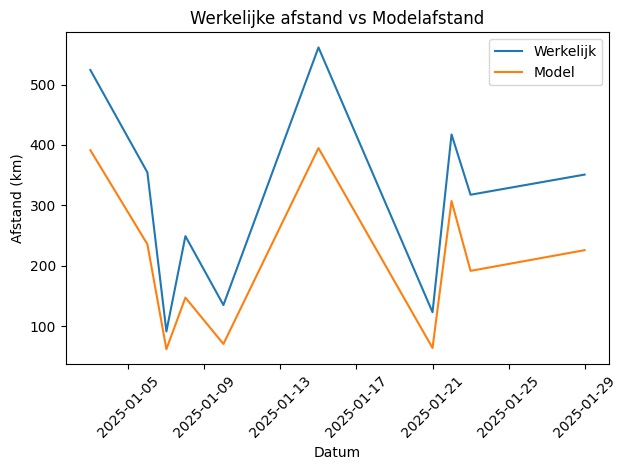

In [71]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_compare["datum"], df_compare["werkelijke_afstand_km"], label="Werkelijk")
plt.plot(df_compare["datum"], df_compare["afstand_km"], label="Model")

plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.ylabel("Afstand (km)")
plt.title("Werkelijke afstand vs Modelafstand")
plt.legend()
plt.tight_layout()
plt.show()

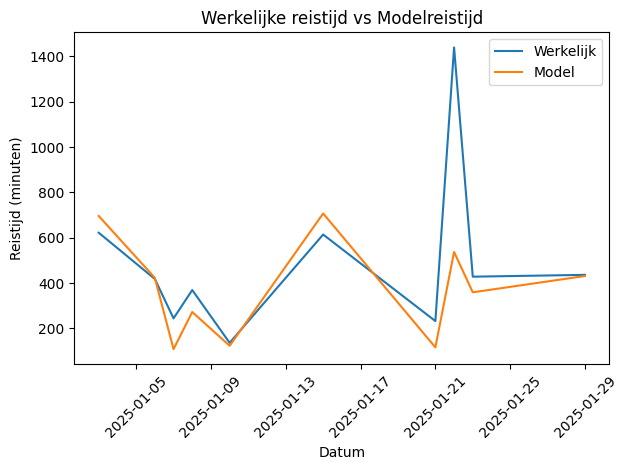

In [73]:
plt.figure()
plt.plot(df_compare["datum"], df_compare["werkelijke_reistijd_min"], label="Werkelijk")
plt.plot(df_compare["datum"], df_compare["model_totale_rijtijd"], label="Model")

plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.ylabel("Reistijd (minuten)")
plt.title("Werkelijke reistijd vs Modelreistijd")
plt.legend()
plt.tight_layout()
plt.show()

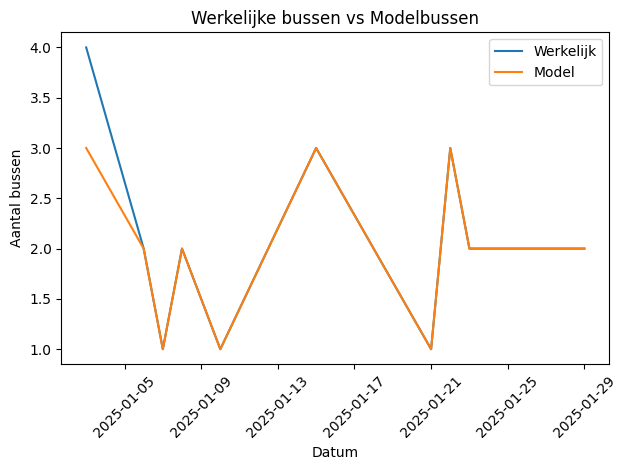

In [74]:
plt.figure()
plt.plot(df_compare["datum"], df_compare["werkelijke_bussen"], label="Werkelijk")
plt.plot(df_compare["datum"], df_compare["voertuigen_gebruikt_model"], label="Model")

plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.ylabel("Aantal bussen")
plt.title("Werkelijke bussen vs Modelbussen")
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
df04['Date'].nunique()

163